# Real ACM Application to Brazilian Government Bonds

This notebook applies the Real ACM model to Brazilian government bonds. The original article

In [1]:
from pyacm import RealACM
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

## Read Data
The zero-yields for nominal and real bonds were constructed with the Nelson-Siegel-Svensson model.

DISCLAIMER: The NSS model is very unstable and this zero yield curve is "homemade", it does not come from official sources like ANBIMA.

In [2]:
xl = pd.ExcelFile("sample_data/nss_zero_curves.xlsx")

# --- Nominal zero-coupon yields (NSS-fitted) ---
nominal_curve = pd.read_excel(xl, sheet_name="nominal_yields", index_col="date", parse_dates=True)
nominal_curve.columns = nominal_curve.columns.astype(int)

# --- Real zero-coupon yields (NSS-fitted) ---
real_curve = pd.read_excel(xl, sheet_name="real_yields", index_col="date", parse_dates=True)
real_curve.columns = real_curve.columns.astype(int)

For the liquidity measure of the paper, we use the NSS fitting error and relative liquidity of nominal and real bonds. Since we do not have a daily measure of open interest, or financial volume, we use as a proxy a measure of total traded risk: volume times DV01.

In [3]:
# Indicator 1: TIPS (NTN-B) NSS fitting errors
fitting_errors = pd.read_excel(xl, sheet_name="real_errors", index_col="date", parse_dates=True)
fitting_errors = fitting_errors["fitting_error"]

# Indicator 2: Relative transaction volume (NTN-B DV01 x Volume / NTN-F DV01 x Volume)
dv01 = pd.read_excel("sample_data/ntn_dv01_volume.xlsx", sheet_name="dv01 stock",
                      index_col="reference date", parse_dates=True)
relative_volume = (dv01.iloc[:, 1] / dv01.iloc[:, 0]).dropna()


# Align dates and standardize
common_idx = fitting_errors.dropna().index.intersection(relative_volume.dropna().index)
fe_std = (fitting_errors.loc[common_idx] - fitting_errors.loc[common_idx].mean()) / fitting_errors.loc[common_idx].std()
rv_std = (relative_volume.loc[common_idx] - relative_volume.loc[common_idx].mean()) / relative_volume.loc[common_idx].std()

# Equal-weighted average, shifted so minimum is zero
liquidity = 0.5 * fe_std + 0.5 * rv_std
liquidity = liquidity - liquidity.min()
liquidity.name = "liquidity"

We grab the IPCA inflation index directly from the BCB's website

In [4]:
ipca_json = pd.read_json(
    "https://api.bcb.gov.br/dados/serie/bcdata.sgs.433/dados?formato=json"
)
ipca_json["data"] = pd.to_datetime(ipca_json["data"], dayfirst=True)
ipca_json = ipca_json.set_index("data").sort_index()
ipca_json["valor"] = ipca_json["valor"].astype(float)

# Convert monthly % change to cumulative price index (base = 100)
cpi = (1 + ipca_json["valor"] / 100).cumprod() * 100
cpi.index = cpi.index.to_period("M").to_timestamp("M")
cpi.name = "cpi"

Align all series to common date range

In [5]:
start = max(nominal_curve.index.min(), real_curve.index.min(), liquidity.index.min())
end = min(nominal_curve.index.max(), real_curve.index.max(), liquidity.index.max())
nominal_curve = nominal_curve.loc[start:end]
real_curve = real_curve.loc[start:end]
liquidity = liquidity.loc[start:end]

## Fit the Model
We use the same specification as the original paper, 3 PCs from the nominal curve, 2 PCs from the real curve and the liquidity measure. We also use the same suggested maturities.

In [6]:
# =========================
# ===== Fit the Model =====
# =========================
# Maturities used in the SUR return regression (paper uses N_N=11, N_R=9)
selected_maturities_n = [6, 12, 24, 36, 48, 60, 72, 84, 96, 108, 120]
selected_maturities_r = [24, 36, 48, 60, 72, 84, 96, 108, 120]

acm = RealACM(
    nominal_curve=nominal_curve,
    real_curve=real_curve,
    liquidity=liquidity,
    cpi=cpi,
    n_factors_n=3,
    n_factors_r=2,
    selected_maturities_n=selected_maturities_n,
    selected_maturities_r=selected_maturities_r,
)

## Charts
We start by decomposing the 5-year nominal yield into its 5 components:

1. Expected Real Rate
2. Real Rate Term Premium
3. Expected Inflation
4. Inflation Premium
5. Liquidity Premium


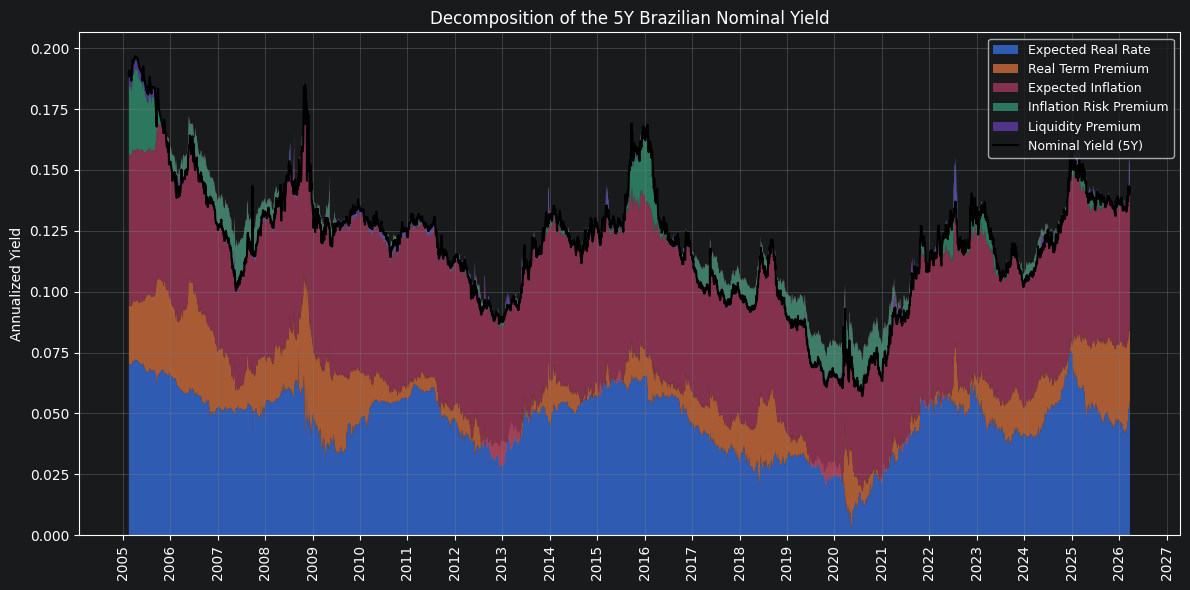

In [7]:
mat = 60  # 5-year maturity (months)
mat_label = f"{mat // 12}Y"

# --- Decomposition components ---
# Liquidity premium on real yields: -B_r[i, liq] * X_liq / (n/12)
tips_cols = real_curve.columns.tolist()
ir = tips_cols.index(mat)
liq_idx = acm.n_factors - 1
X_liq = acm.pc_factors_d.iloc[:, liq_idx]
liq_premium = -acm.B_r[ir, liq_idx] * X_liq / (mat / 12)
liq_premium.name = "Liquidity Premium"

expected_real_rate = acm.rny_r[mat]
real_tp = acm.tp_r[mat] - liq_premium
expected_inflation = acm.rny_n[mat] - acm.rny_r[mat]
inflation_rp = acm.irp[mat]

# --- Stacked area chart ---
fig, ax = plt.subplots(figsize=(12, 6))

components = pd.DataFrame({
    "Expected Real Rate": expected_real_rate,
    "Real Term Premium": real_tp,
    "Expected Inflation": expected_inflation,
    "Inflation Risk Premium": inflation_rp,
    "Liquidity Premium": liq_premium,
})

ax.stackplot(
    components.index,
    components.T.values,
    labels=components.columns,
    alpha=0.8,
)
ax.plot(nominal_curve[mat], color="black", lw=1.5, label=f"Nominal Yield ({mat_label})")
ax.set_title(f"Decomposition of the {mat_label} Brazilian Nominal Yield")
ax.set_ylabel("Annualized Yield")
ax.xaxis.grid(color="grey", linestyle="-", linewidth=0.5, alpha=0.5)
ax.yaxis.grid(color="grey", linestyle="-", linewidth=0.5, alpha=0.5)
ax.legend(loc="upper right", fontsize=9)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(rotation=90, axis="x")

plt.tight_layout()
plt.show()

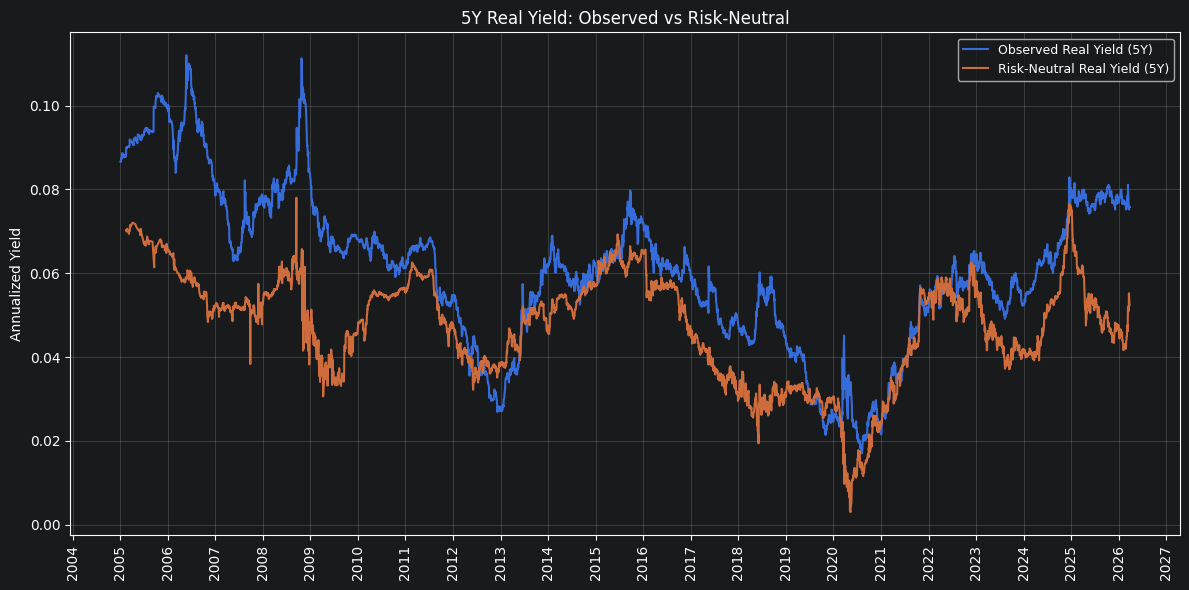

In [8]:
# --- Chart 2: Observed vs Expected Real Rate ---
fig2, ax2 = plt.subplots(figsize=(12, 6))
ax2.plot(real_curve[mat], lw=1.5, label=f"Observed Real Yield ({mat_label})")
ax2.plot(acm.rny_r[mat], lw=1.5, label=f"Risk-Neutral Real Yield ({mat_label})")
ax2.set_title(f"{mat_label} Real Yield: Observed vs Risk-Neutral")
ax2.set_ylabel("Annualized Yield")
ax2.xaxis.grid(color="grey", linestyle="-", linewidth=0.5, alpha=0.5)
ax2.yaxis.grid(color="grey", linestyle="-", linewidth=0.5, alpha=0.5)
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.tick_params(rotation=90, axis="x")
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()